# Grand Tours data analysis

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import re
import os
# plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import style
plt.style.use('bmh')
#

In [4]:
db_path = "data/grand_tours.db"
# db_path = "data/training.db"

In [5]:
# Function to get the maximum stage # for a given tour
def get_max_stage_from_year(db_path, table_name, year_num):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    cursor.execute(f"""SELECT stage FROM "{table_name}" WHERE year = "{year_num}" """)
    rows = cursor.fetchall()
    # Extract stage numbers and count frequencies
    stage_counts = {}
    for row in rows:
        stage_text = row[0]
        match = re.search(r'\d+', stage_text)
        if match:
            stage_number = int(match.group()) if match else None
            stage_counts[stage_number] = stage_counts.get(stage_number, 0) + 1
    #
    conn.close()
    return max(stage_counts) 

In [7]:
# Function to plot the frequency of rows for a given year and given tour
def get_yearly_summary_of_tours(db_path, table_name):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    if table_name == "tdf_results":
        tour_name = "tdf"
    elif table_name == "giro_results":
        tour_name = "giro"
    elif table_name == "vuelta_results":
        tour_name = "vuelta"
    else:
        raise ValueError("Invalid table name.")
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    # Retrieve unique years and their counts
    cursor.execute(f"""SELECT year, COUNT(*) FROM "{table_name}" GROUP BY year""")
    rows = cursor.fetchall()
    #
    years = []
    freqs = []
    max_stages =[]
    for year, freq in rows:
        max_stage = get_max_stage_from_year(db_path, table_name, year)  
        #
        if max_stage is not None:
            years.append(year)
            freqs.append(freq)
            max_stages.append(max_stage)
    #
    #-----------------------------------#
    # Create histogram
    fig, ax1 = plt.subplots(figsize=(12,4))
    #
    ax1.bar(years, freqs, color=tour_colors[tour_name], alpha=0.6, label='Frequency', ec='k', lw=0.5)
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Frequency (no. of rows)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    xvalues = np.linspace(1910,2030,13, dtype=int)
    plt.xticks(xvalues, [str(x) for x in xvalues], rotation=0) 
    # 
    ax2 = ax1.twinx()
    ax2.plot(years,max_stages, color='r', marker='.', linestyle='-', label='Max Stage')
    ax2.set_ylabel('Number of Stages', color='r', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax2.set_ylim(ymin=0)
    # 
    plt.title( tour_name + " yearly summary of data", fontsize=10)
    # plt.savefig("Plots/"+tour_name + "_"+ "data_yearly_summary.png", bbox_inches='tight')
    fig.tight_layout()
    plt.show()
    #-----------------------------------#
    #
    cursor.close()
    conn.close()
    return None

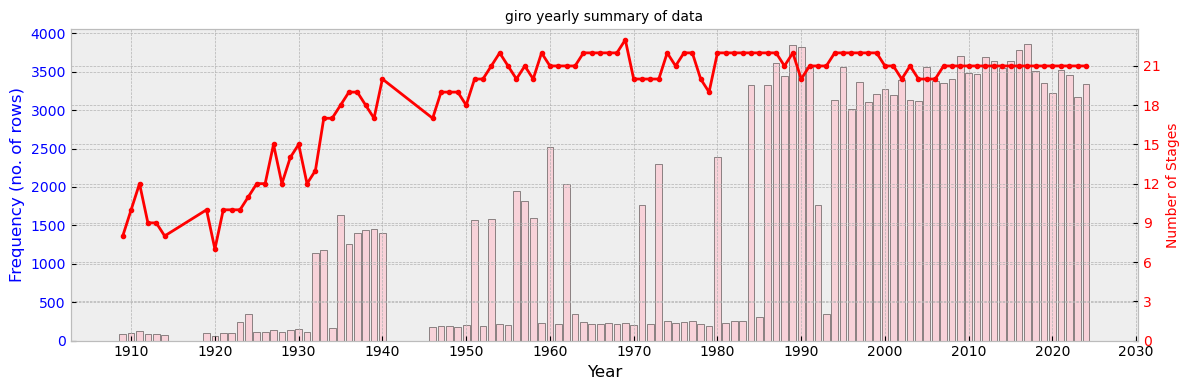

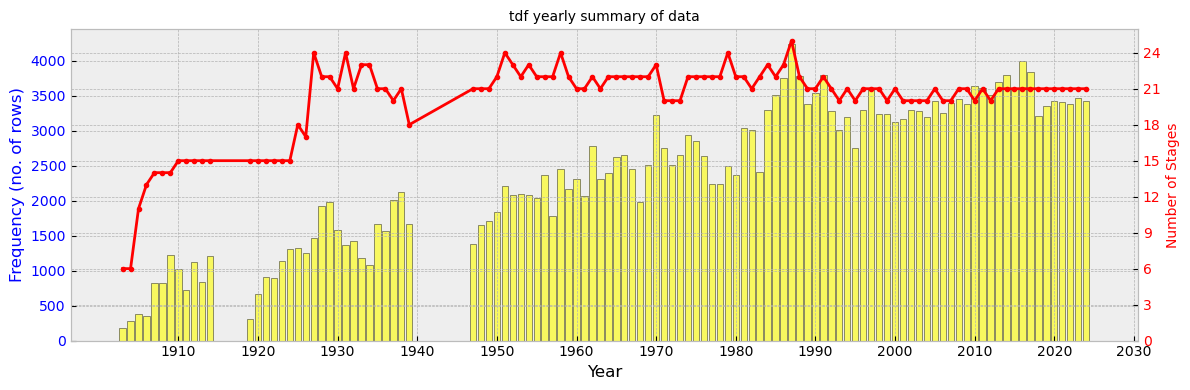

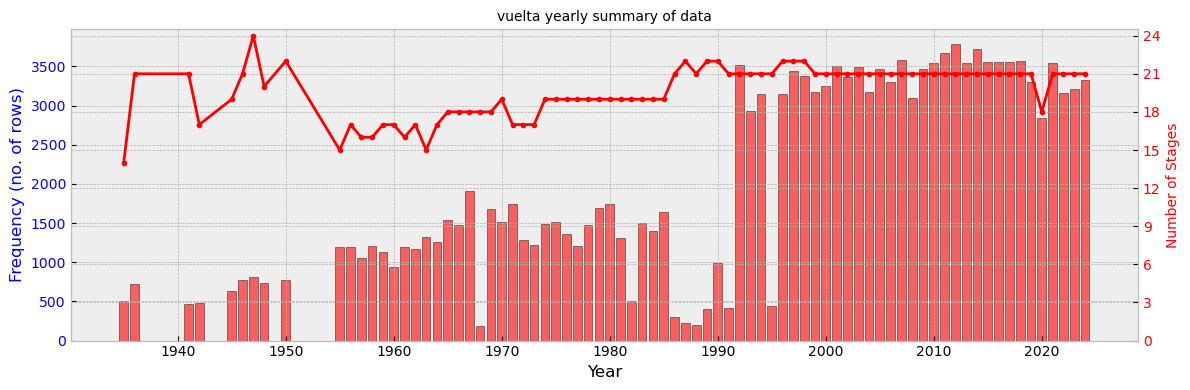

In [8]:
## yearly summary of one of the three tours
get_yearly_summary_of_tours(db_path, "giro_results")
get_yearly_summary_of_tours(db_path, "tdf_results")
get_yearly_summary_of_tours(db_path, "vuelta_results")

In [ ]:
# Function to plot the unmber of rows for a specific tour and specific year
def get_summary_of_specific_tour_year(db_path, table_name, year_num):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    if table_name == "tdf_results":
        tour_name = "tdf"
    elif table_name == "giro_results":
        tour_name = "giro"
    elif table_name == "vuelta_results":
        tour_name = "vuelta"
    else:
        raise ValueError("Invalid table name.")
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    cursor.execute(f"""SELECT stage FROM "{table_name}" WHERE year = "{year_num}" """)
    rows = cursor.fetchall()
    # get stage numbers and their frequencies
    stage_counts = {}
    for row in rows:
        stage_text = row[0]
        match = re.search(r'\d+', stage_text)
        if match:
            stage_number = int(match.group())
            stage_counts[stage_number] = stage_counts.get(stage_number, 0) + 1
    #
    stages = []
    rider_freqs = []
    for stage, freq in sorted(stage_counts.items()):
        if rider_freqs is not None:
            stages.append(stage)
            rider_freqs.append(freq)
    #
    #-----------------------------------#
    fig, ax1 = plt.subplots(figsize=(7,3))
    #
    ax1.bar(stages, rider_freqs, color=tour_colors[tour_name], alpha=1.0, label="GRO-"+ str(year_num), ec='k', lw=0.5)
    ax1.set_xlabel('Stage')
    ax1.set_ylabel('No. of riders', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    xvalues = np.linspace(1,max(stage_counts), dtype=int)
    plt.xticks(xvalues, [str(x) for x in xvalues]) 
    #
    plt.title(tour_name + "-"+ str(year_num),fontsize=12)
    plt.savefig("Plots/" + tour_name + "_"+ str(year_num) + "_summary.png", bbox_inches='tight')
    fig.tight_layout()
    plt.show()
    #-----------------------------------#
    # 
    cursor.close()
    conn.close()

In [ ]:
get_summary_of_specific_tour_year(db_path, "tdf_results",2009)
get_summary_of_specific_tour_year(db_path, "giro_results",2010)
get_summary_of_specific_tour_year(db_path, "vuelta_results",2011)

## Exploring grand_tours Database using pandas

In [18]:
gt_db_path = "data/grand_tours.db"
# db_path ="data/training.db"

In [20]:
conn = sqlite3.connect(gt_db_path)
# table_name = "tdf_results"
# table_name = "giro_results"
# table_name = "vuelta_results"
#
table_name = "segments_data"
# table_name = "stats_data"
gt_df = pd.read_sql_query(f"""SELECT * from "{table_name}" """, conn)

# df.shape
gt_df.columns
# df.dtypes

Index(['activity_id', 'athlete_id', 'date', 'distance', 'segment', 'tour',
       'year'],
      dtype='object')

In [ ]:
gt_df.head(10)

,activity_id,athlete_id,date,distance,segment,tour,year
0,50090631,505408,April 22 2013,166.86,"{""segment_name"": [""Rotonda S\u00b4Habitat - Ro...",giro,2013
1,50269241,110144,April 23 2013,136.07,"{""segment_name"": [""Rilancio dalla piazza"", ""St...",giro,2013
2,50449480,110144,April 24 2013,140.28,"{""segment_name"": [""Rilancio dalla piazza"", ""St...",giro,2013
3,50599840,1514397,April 25 2013,37.10,"{""segment_name"": [""Salita dalla Chiesa di Cris...",giro,2013
4,50847673,505408,April 26 2013,48.97,{},giro,2013
5,50847682,505408,April 25 2013,66.86,"{""segment_name"": [""A414 to Main Rd Boreham"", ""...",giro,2013
6,50847727,505408,April 23 2013,57.64,"{""segment_name"": [""SVCC sprint"", ""Cami de Can ...",giro,2013
7,51332935,1514397,April 27 2013,75.18,"{""segment_name"": [""Boulevard des moulins !"", ""...",giro,2013
8,51602847,505408,April 30 2013,17.25,"{""segment_name"": [""e21/10- sw"", ""MAD 10. 1st m...",giro,2013
9,51812142,1514397,May 1 2013,26.22,"{""segment_name"": [""Alpino - Castenedolo"", ""Su ...",giro,2013


In [ ]:
gt_df.sort_values('year')

,activity_id,athlete_id,date,distance,segment,tour,year
0,50090631,505408,April 22 2013,166.86,"{""segment_name"": [""Rotonda S\u00b4Habitat - Ro...",giro,2013
49,62605480,1855274,Jun 21 2013,45.78,"{""segment_name"": [""sprint lwu"", ""Leenstraat"", ...",tdf,2013
82,64309942,1855274,Jun 26 2013,26.89,"{""segment_name"": [""Monte Melsen"", ""sprint lwu""...",tdf,2013
83,64310017,1855274,Jun 27 2013,52.64,"{""segment_name"": [""mont\u00e9e du figuier"", ""r...",tdf,2013
84,64310074,1855274,Jun 28 2013,52.25,"{""segment_name"": [""Bosse dU Stagnolu"", ""mont\u...",tdf,2013
...,...,...,...,...,...,...,...
36595,11237796591,197359,April 22 2024,79.24,"{""segment_name"": [""L\u00e9opolda - CDV"", ""Down...",giro,2024
36594,11237778788,41438962,April 22 2024,76.81,"{""segment_name"": [""Faux plat montant avant Pla...",giro,2024
36582,11237389702,3732430,April 22 2024,30.43,"{""segment_name"": [""Esprint RolserJoseJorroUlb""...",giro,2024
36581,11237381344,2885876,April 22 2024,24.59,"{""segment_name"": [""Baixant d'Escaldes"", ""Carre...",giro,2024


In [8]:
# Function to plot the yearly data of the strava table
def get_pandas_summary_of_starava_data(db_path, table_name):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql(f"""SELECT * FROM "{table_name}" """, conn)  
    conn.close()
    #
    # Create a pivot table to count 'tour' types per 'year'
    pivot_df = df.pivot_table(index='year', columns='tour', aggfunc='size', fill_value=0)
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    #-----------------------------------#
    fig, ax = plt.subplots(figsize=(9, 4))
    pivot_df.plot(kind='bar', stacked=True, color=[tour_colors[tour] for tour in pivot_df.columns], ax=ax, ec='k', lw=0.5)
    # Annotate each bar with the total frequency count per year
    for idx, year in enumerate(pivot_df.index):
        total_count = pivot_df.loc[year].sum()
        ax.text(idx, total_count + 0.5, str(total_count), ha='center', va='bottom', fontsize=10, color='black')
    #
    ax.set_title(table_name + " frequency plot by year and tour type", fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Frequency')
    ax.legend(title='Tour')
    ax.set_xticks(range(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.index, rotation=45)
    fig.tight_layout()
    plt.savefig("Plots/"+ table_name + "_"+ "frequency_plot_by_year.png", bbox_inches='tight')
    plt.show()
    #-----------------------------------#
    return None

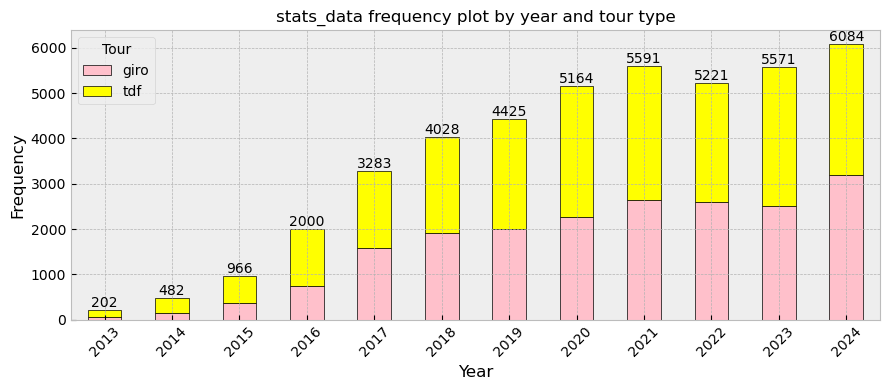

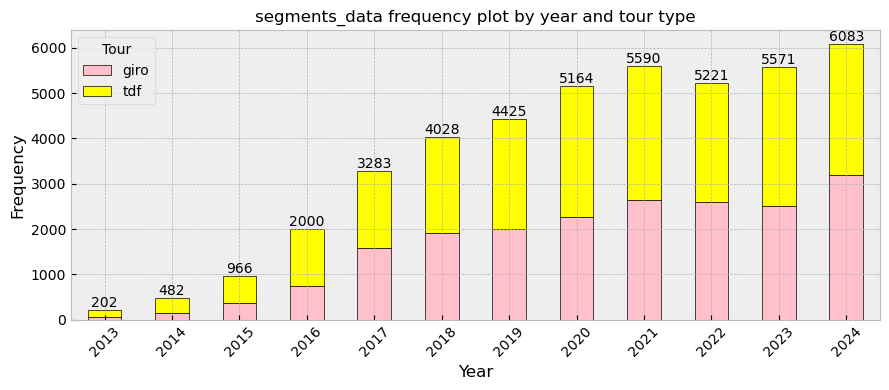

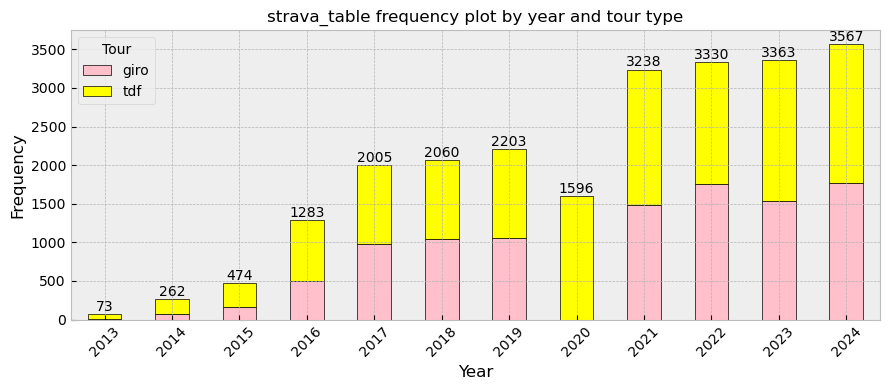

In [ ]:
get_pandas_summary_of_starava_data(gt_db_path, "stats_data")
get_pandas_summary_of_starava_data(gt_db_path, "segments_data")
get_pandas_summary_of_starava_data(gt_db_path, "strava_table")

In [11]:
def get_athlets_summary_for_specific_tour_year(db_path, table_name, tour_name, year):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql(f"""SELECT * FROM "{table_name}" """, conn)  
    conn.close()
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    # Filter data for the selected year and tour
    filtered_df = df[(df['year'] == year) & (df['tour'] == tour_name)]
    # Count the frequency of each unique athlete_id then sort that by index
    id_counts = filtered_df['athlete_id'].value_counts().sort_index()
    #
    # Sort the entire DataFrame first and then selects the top m rows.
    m = 100
    top_m_id_counts = id_counts.sort_values(ascending=False).head(m)
    #
    #-----------------------------------#
    fig, ax2 = plt.subplots(figsize=(15, 4))
    #
    top_m_id_counts.plot(kind='bar', color=tour_colors[tour_name] , ax=ax2, ec='k', lw=0.5)
    # 
    for idx, id_num in enumerate(top_m_id_counts.index):
        total_count = top_m_id_counts.loc[id_num].sum()
        ax2.text(idx, total_count + 0.5, str(total_count), ha='center', va='bottom', fontsize=8, color='black')
    #
    ax2.set_title(f"{table_name} frequency of top " + str(m) + f" uploaders for {year}-{tour_name}")
    ax2.set_xlabel('athlete_ID')
    ax2.set_ylabel('Frequency')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.savefig("Plots/"+ table_name + "_"+ "frequency_by_athlet_id_for_" + str(year) + "_" + tour_name +".png", bbox_inches='tight')
    plt.show()
    #-----------------------------------#
    return None

#### Top m uploaders of giro

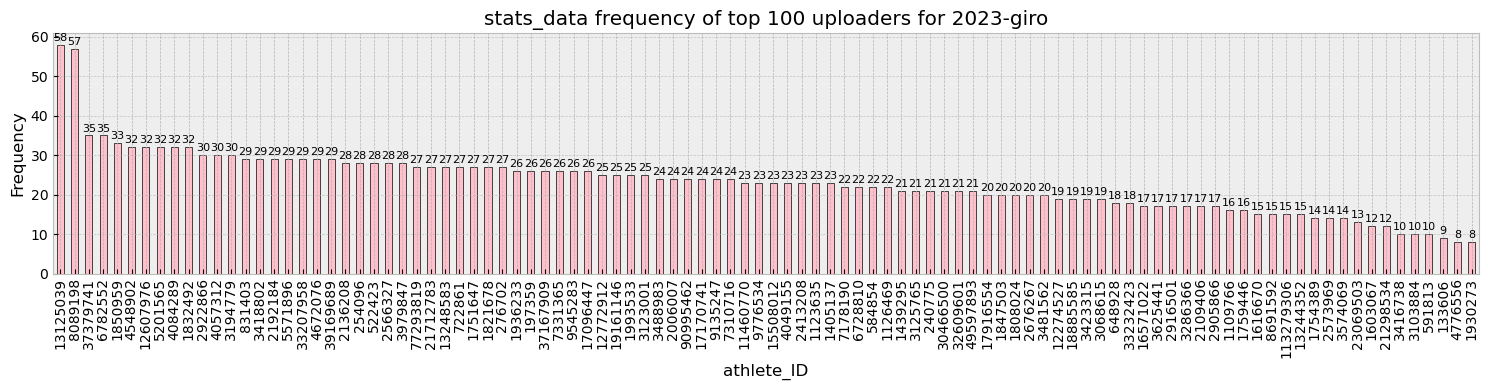

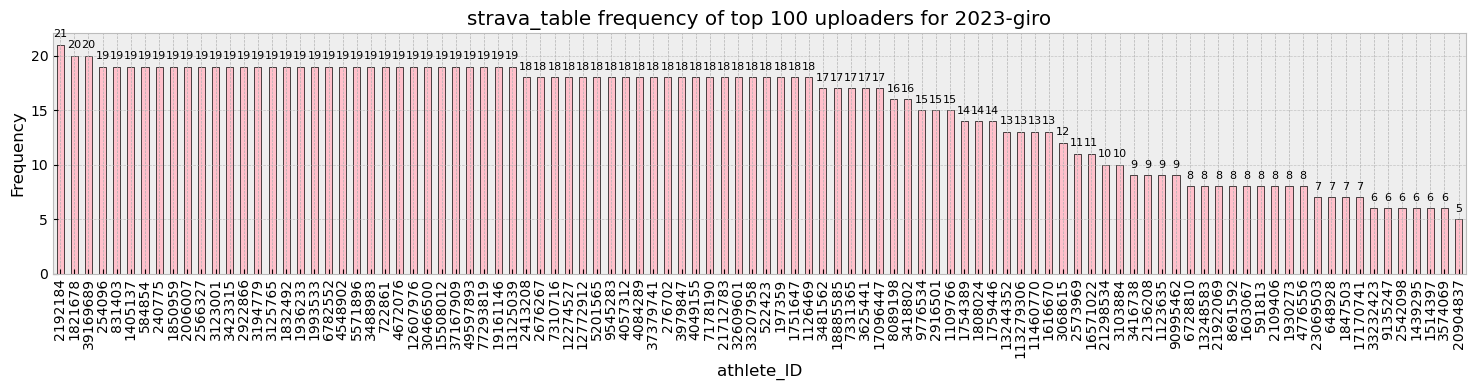

In [ ]:
gt_year = 2023 #pick a year between 2013 & 2024
get_athlets_summary_for_specific_tour_year(gt_db_path,'stats_data','giro', gt_year)
# get_athlets_summary_for_specific_tour_year(gt_db_path,'segments_data','giro', gt_year)
get_athlets_summary_for_specific_tour_year(gt_db_path,'strava_table','giro', gt_year)

#### Top m uploaders of tdf

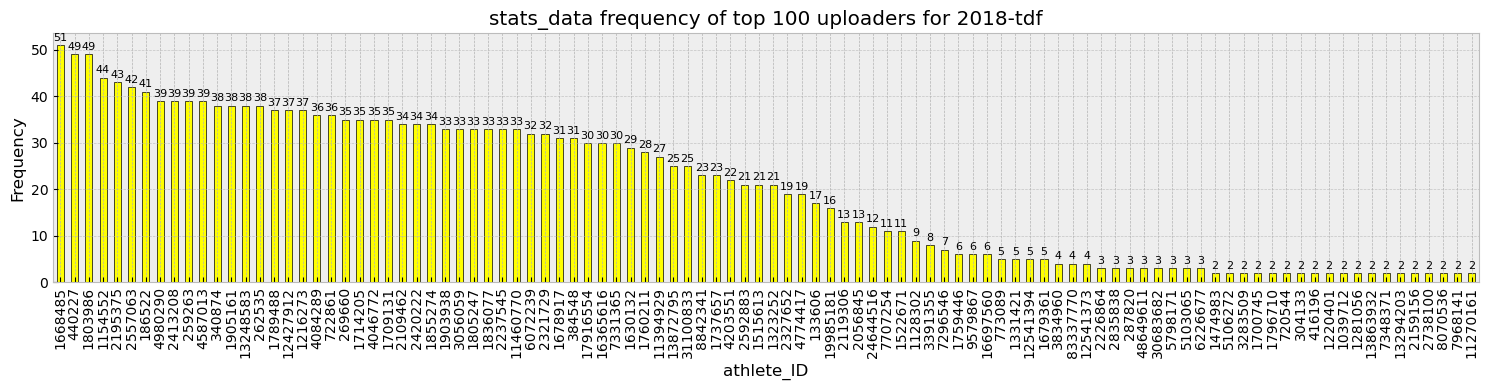

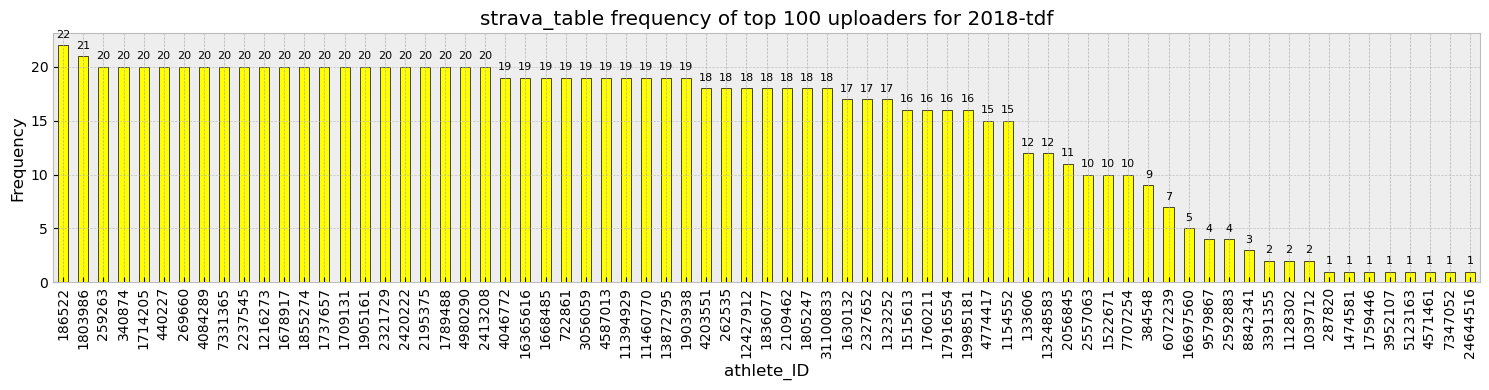

In [ ]:
gt_year = 2018 #pick a year between 2013 & 2024
get_athlets_summary_for_specific_tour_year(gt_db_path,'stats_data','tdf', gt_year)
# get_athlets_summary_for_specific_tour_year(gt_db_path,'segments_data','tdf', yeagt_yearr)
get_athlets_summary_for_specific_tour_year(gt_db_path,'strava_table','tdf', gt_year)

## Exploring strava_segments Database from training.db using pandas

I used the code [  ] to parse the segements column of training.db. 
Since activity_id, athlete_id, and segment_name can't be a good key I used just an index counter as the primary key. 

In [84]:
strava_db_path = "data/strava_segments.db"

In [ ]:
strava_conn = sqlite3.connect(strava_db_path)
table_name = "segment_activity"
strava_df = pd.read_sql_query(f"""SELECT * from "{table_name}" """, strava_conn)

print("\n", strava_df.shape)
print("\n", strava_df.dtypes)
print("")



 (1201230, 12)

 id                        int64
activity_id               int64
athlete_id                int64
segment_name             object
segment_distance_km     float64
segment_vert_m          float64
segment_grade           float64
segment_time_seconds    float64
segment_speed_kph       float64
power_watt              float64
heart_rate_bpm          float64
vertical_ascent_m       float64
dtype: object



In [87]:
strava_df.head(20)

,id,activity_id,athlete_id,segment_name,segment_distance_km,segment_vert_m,segment_grade,segment_time_seconds,segment_speed_kph,power_watt,heart_rate_bpm,vertical_ascent_m
0,1,6929029131,1821678,Del puti al gim,1.03,2.0,0.2,114.0,32.7,NaN,NaN,NaN
1,2,6929029131,1821678,Osinbiribil - Kostorbe,0.73,9.0,1.0,88.0,29.9,NaN,NaN,NaN
2,3,6929029131,1821678,Repecho al Puente en la Gi-636,1.13,15.0,1.3,133.0,30.7,NaN,NaN,NaN
3,4,6929029131,1821678,Beraqueta Kalea Climb,0.73,137.0,18.8,94.0,27.9,NaN,NaN,5254.0
4,5,6929029131,1821678,LA CUESTA DEL DIABLO,0.29,12.0,4.2,NaN,25.7,NaN,NaN,NaN
5,6,6929029131,1821678,Anzaran- Ficoba,1.16,14.0,0.1,137.0,30.6,NaN,NaN,NaN
6,7,6929029131,1821678,Sprint a Francia,0.36,6.0,1.2,NaN,29.1,NaN,NaN,NaN
7,8,6929029131,1821678,Climb Hopital Marin - Virage Galbarreta,0.69,29.0,4.2,125.0,19.9,NaN,NaN,NaN
8,9,6929029131,1821678,sprint,0.34,14.0,3.9,NaN,21.2,NaN,NaN,NaN
9,10,6929029131,1821678,Route de La Glacière,1.63,84.0,5.1,313.0,18.8,NaN,NaN,962.0


Plot the distribution of the segment distances 

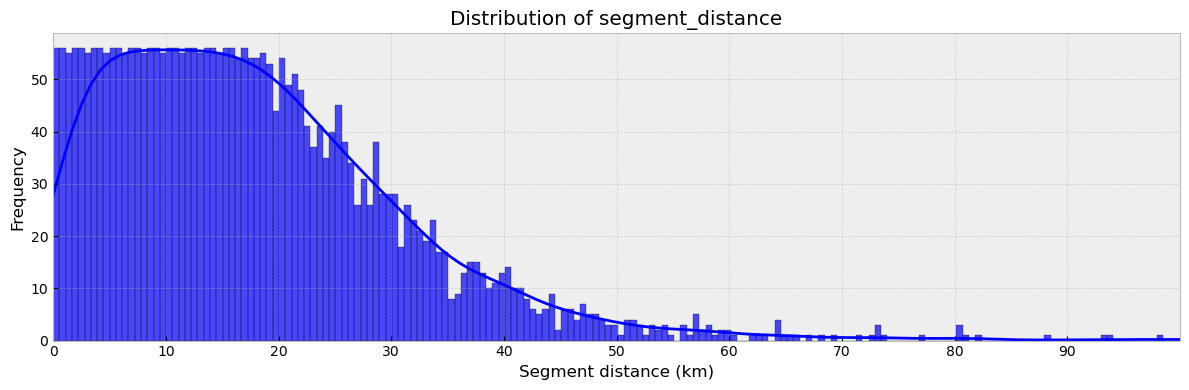

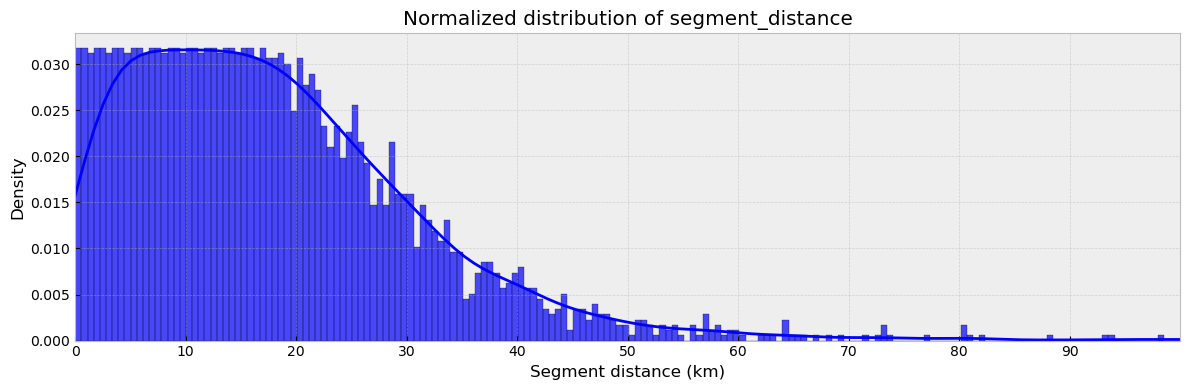

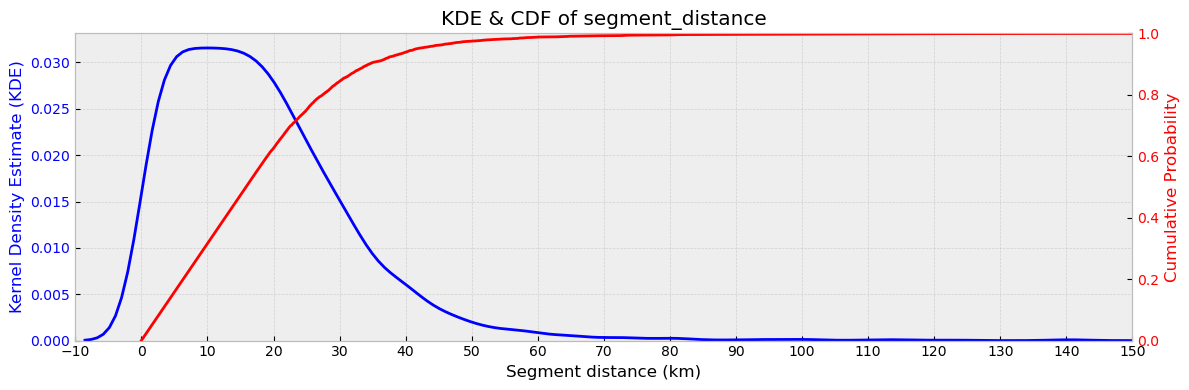

In [83]:
# 
table_name = 'segment_activity'
conn = sqlite3.connect(strava_db_path)
distance_query = f"SELECT DISTINCT segment_distance_km FROM {table_name}"
distances_df = pd.read_sql_query(distance_query, conn)
conn.close()

#-----------------------------------#
# Plot histogram 
fig1, ax1 = plt.subplots(figsize=(12, 4))
sns.histplot(distances_df['segment_distance_km'], bins=300, kde=True, color='blue', edgecolor='black', alpha=0.7)
ax1.set_xlabel("Segment distance (km)" )
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of segment_distance")
ax1.set_xlim(0, 100)
ax1.set_xticks(np.arange(0, 100, 10))
plt.grid(True, linestyle='--', alpha=0.5)
fig1.tight_layout()
plt.show()
#-----------------------------------#

#-----------------------------------#
# Plot normalized histogram
fig2, ax2 = plt.subplots(figsize=(12, 4))
sns.histplot(distances_df['segment_distance_km'], bins=300, kde=True, color='blue', edgecolor='black', alpha=0.7, stat="density", ax=ax2)
ax2.set_xlabel("Segment distance (km)" )
ax2.set_ylabel("Density")
ax2.set_title("Normalized distribution of segment_distance")
ax2.set_xlim(0, 100)
ax2.set_xticks(np.arange(0, 100, 10))
plt.grid(True, linestyle='--', alpha=0.5)
fig2.tight_layout()
plt.show()
#-----------------------------------#

#-----------------------------------#
# Plot Kernel Density Estimate (KDE) and CDF on the same plot
fig3, ax3 = plt.subplots(figsize=(12, 4))
# KDE plot 
sns.kdeplot(distances_df['segment_distance_km'], color='blue', lw=2, ax=ax3)
ax3.set_xlabel("Segment distance (km)" )
ax3.set_ylabel("Kernel Density Estimate (KDE)", color='blue')
ax3.tick_params(axis='y', labelcolor='blue')
ax3.set_xlim(-10, 150)
ax3.set_xticks(np.arange(-10, 151, 10)) 
#
ax4 = ax3.twinx()
# CDF plot
sorted_seg_distances = np.sort(distances_df['segment_distance_km'])
cdf = np.arange(1, len(sorted_seg_distances) + 1) / len(sorted_seg_distances)
ax4.plot(sorted_seg_distances, cdf, color='red', linewidth=2)
ax4.set_ylabel("Cumulative Probability", color='red')
ax4.tick_params(axis='y', labelcolor='red')
#
ax3.set_ylim(0, None)  
ax4.set_ylim(0, 1) 
#
ax3.grid(True, linestyle='--', alpha=0.5)
ax4.grid(False)
#
plt.title(f"KDE & CDF of segment_distance")
fig3.tight_layout()
plt.show()
#-----------------------------------#


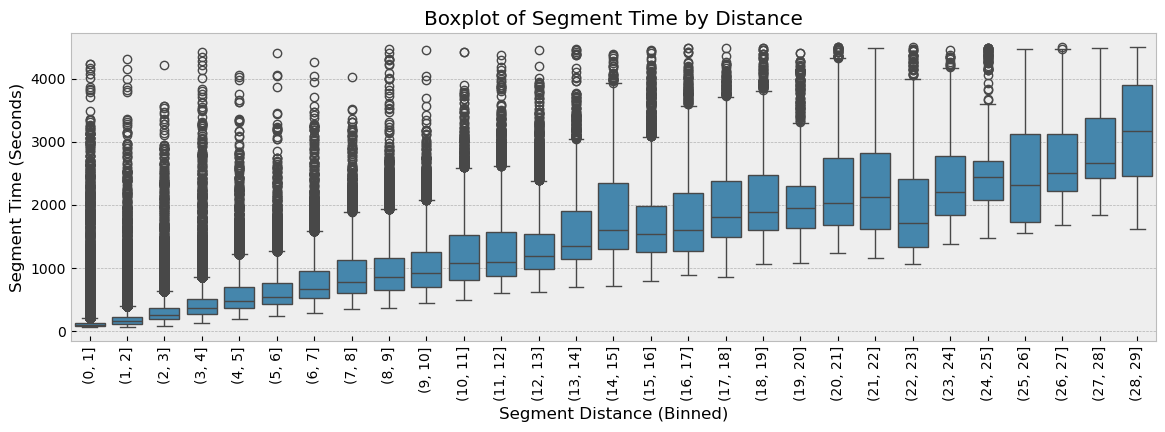

In [ ]:
#
table_name = 'segment_activity'
conn = sqlite3.connect(strava_db_path)
seg_time_df = pd.read_sql_query(f"SELECT segment_distance_km, segment_time_seconds FROM {table_name}", conn)
conn.close()

# Define segment distance bins
bin_edges = np.arange(0, 30, 1)
# Define a cut-off to remove segment_time values above a threshold
threshold = 4500
time_df_filtered = seg_time_df[seg_time_df['segment_time_seconds'] <= threshold]  # Filter value
#
# df['distance_bin'] = pd.cut(df['segment_distance_km'], bins=bin_edges, right=False)

# Create a pivot table to count occurrences of segment times in each bin
# heatmap_data = pd.crosstab(df['distance_bin'], pd.cut(df['segment_time_seconds'], bins=100))
#
# # Plot the heatmap
# plt.figure(figsize=(12, 6))
# sns.heatmap(heatmap_data, cmap='viridis', cbar=True, xticklabels=False, yticklabels=True)
# plt.xlabel("Segment Time (Binned)")
# plt.ylabel("Segment Distance (Binned)")
# plt.title("Heatmap of Segment Time Distribution by Segment Distance")
# plt.show()


# Boxplot of segment time distribution per distance bin
plt.figure(figsize=(14, 4))
# sns.boxplot(x=pd.cut(df['segment_distance_km'], bins=bin_edges), y=df['segment_time_seconds'])
sns.boxplot(x=pd.cut(time_df_filtered['segment_distance_km'], bins=bin_edges), y=time_df_filtered['segment_time_seconds'])
#
plt.xticks(rotation=90) 
plt.xlabel("Segment Distance (Binned)")
plt.ylabel("Segment Time (Seconds)")
plt.title("Boxplot of Segment Time by Distance")
plt.show()

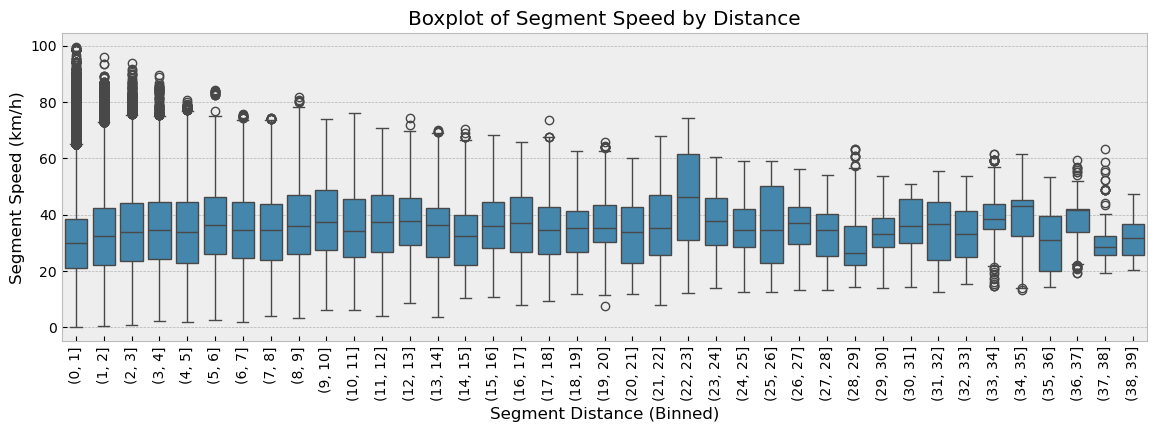

In [94]:
#
table_name = 'segment_activity'
conn = sqlite3.connect(strava_db_path)
seg_speed_df = pd.read_sql_query(f"SELECT segment_distance_km, segment_speed_kph FROM {table_name}", conn)
conn.close()

# Define segment distance bins
bin_edges = np.arange(0, 40, 1)
# Define a cut-off to remove segment_time values above a threshold
threshold = 100
speed_df_filtered = seg_speed_df[seg_speed_df['segment_speed_kph'] <= threshold]  # Filter value

# Boxplot of segment time distribution per distance bin
plt.figure(figsize=(14, 4))
sns.boxplot(x=pd.cut(speed_df_filtered['segment_distance_km'], bins=bin_edges), y=speed_df_filtered['segment_speed_kph'])
#
plt.xticks(rotation=90) 
plt.xlabel("Segment Distance (Binned)")
plt.ylabel("Segment Speed (km/h)")
plt.title("Boxplot of Segment Speed by Distance")
plt.show()

In [11]:
# Function to plot what the data looks like for each athlete (tme,  speed, power, heart beat)
def get_entire_db_summary_by_athlete_id(strava_db_path, table_name, output_dir):
    conn = sqlite3.connect(strava_db_path)
    athlete_query = f"SELECT DISTINCT athlete_id FROM {table_name}"
    athlete_ids = pd.read_sql_query(athlete_query, conn)['athlete_id'].tolist()

    # Ensure directory exists for saving plots
    os.makedirs(output_dir, exist_ok=True)

    ## ----- for drawing reference lines 
    seg_dist_x = np.linspace(0, 30, 100) 
    VAM_x = np.linspace(0, 3000, 500) 
    #
    seg_time_slow = 60 * seg_dist_x  
    seg_time_fast = 240 * seg_dist_x  
    #
    seg_speed_slow = (10/2500) * VAM_x  
    seg_speed_fast = (30/1000) * VAM_x  
    #
    with np.errstate(divide='ignore'):
        seg_time = np.where(VAM_x != 0., 1000000/(4*VAM_x), -2)
    ## -----
    #
    # Loop through each athlete_id
    for athlete_id in athlete_ids:
        print(f"Processing athlete_id {athlete_id}...")
        query = f"""
            SELECT activity_id, segment_distance_km, segment_time_seconds, segment_speed_kph, 
                power_watt, heart_rate_bpm, vertical_ascent_m
            FROM {table_name}
            WHERE athlete_id = ?
        """
        df = pd.read_sql_query(query, conn, params=(athlete_id,))
        #
        # Skip if no data for this athlete
        if df.empty:
            print(f"No data found for athlete_id {athlete_id}, skipping...")
            continue

        # Create figure with 2 rows and 3 columns
        fig, axs = plt.subplots(2, 3, figsize=(15, 8))
        plt.subplots_adjust(hspace=0.4)

        # Define unique markers and colors for different activities
        markers = ['o', 's', 'D', '^', 'v', 'p', 'X', '*', '<', '>']
        colors = plt.cm.tab10.colors  # 10 distinct colors

        # Create a legend handle for each activity_id
        legend_handles = []
        axis_limits = {
            (0, 0): {'xlim': (0, 30), 'ylim': (0, 5000)},  # segment_distance_km vs segment_time_seconds
            (0, 1): {'xlim': (0, 30), 'ylim': (0, 80)},    # segment_distance_km vs segment_speed_kph
            (0, 2): {'xlim': (0, 30), 'ylim': (0, 800)},   # segment_distance_km vs power_watt
            (1, 0): {'xlim': (0, 30), 'ylim': (0, 200)},   # segment_distance_km vs heart_rate_bpm
            (1, 1): {'xlim': (0, 3000), 'ylim': (0, 5000)},# vertical_ascent_m vs segment_time_seconds
            (1, 2): {'xlim': (0, 3000), 'ylim': (0, 60)}   # vertical_ascent_m vs segment_speed_kph
        }

        # Group data by activity_id and plot
        for i, (activity_id, group) in enumerate(df.groupby('activity_id')):
            color = colors[i % len(colors)]
            marker = markers[i % len(markers)]
            mSize = 4
            # Scatter plots
            axs[0, 0].scatter(group['segment_distance_km'], group['segment_time_seconds'], color=color, marker=marker, s=mSize)
            axs[0, 1].scatter(group['segment_distance_km'], group['segment_speed_kph'], color=color, marker=marker, s=mSize)
            axs[0, 2].scatter(group['segment_distance_km'], group['power_watt'], color=color, marker=marker, s=mSize)
            axs[1, 0].scatter(group['segment_distance_km'], group['heart_rate_bpm'], color=color, marker=marker, s=mSize)
            axs[1, 1].scatter(group['vertical_ascent_m'], group['segment_time_seconds'], color=color, marker=marker, s=mSize)
            axs[1, 2].scatter(group['vertical_ascent_m'], group['segment_speed_kph'], color=color, marker=marker, s=mSize)

            # Add to legend handles only once per activity_id
            #legend_handles.append(plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=color, markersize=8, label=f'Activity {activity_id}'))

        # Add reference lines 
        axs[0, 0].plot(seg_dist_x, seg_time_slow, linestyle='dashed', lw = 1, color='r')
        axs[0, 0].plot(seg_dist_x, seg_time_fast, linestyle='dashed', lw = 1, color='gray')
        #
        axs[1, 2].plot(VAM_x, seg_speed_slow, linestyle='dashed', lw = 1, color='r')
        axs[1, 2].plot(VAM_x, seg_speed_fast, linestyle='dashed', lw=1, color='gray')
        #
        axs[1, 1].plot(VAM_x, seg_time, linestyle='dashed', lw = 1, color='r')
        
        # Set labels and titles for each subplot
        plot_labels = [
            ("Segment Distance (km)", "Segment Time (seconds)", "Segment Distance vs Time"),
            ("Segment Distance (km)", "Segment Speed (kph)", "Segment Distance vs Speed"),
            ("Segment Distance (km)", "Power (Watt)", "Segment Distance vs Power"),
            ("Segment Distance (km)", "Heart Rate (bpm)", "Segment Distance vs Heart Rate"),
            ("Vertical Ascent (m)", "Segment Time (seconds)", "Vertical Ascent vs Time"),
            ("Vertical Ascent (m)", "Segment Speed (kph)", "Vertical Ascent vs Speed")
        ]
        #
        for (i, j), (xlabel, ylabel, title) in zip(axis_limits.keys(), plot_labels):
            axs[i, j].set_xlabel(xlabel, fontsize=10)
            axs[i, j].set_ylabel(ylabel, fontsize=10)
            axs[i, j].set_title(title)
            #
            # Apply custom x and y limits
            axs[i, j].set_xlim(axis_limits[(i, j)]['xlim'])
            axs[i, j].set_ylim(axis_limits[(i, j)]['ylim'])
        # 
        fig.suptitle(f'athlete {athlete_id} all activities', fontsize=12)
        fig.tight_layout()
        plt.savefig(os.path.join(output_dir, f"id_{athlete_id}_summary.png"), bbox_inches='tight')
        #
        print(f"Saved plot for athlete_id {athlete_id} \n")
        # fig.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.05, 0.5), title="Activity IDs", frameon=False, ncol=1)
        # plt.show()
        plt.close(fig)  
    conn.close()
    print("\nProcessing complete for all athletes.")
    return None

In [ ]:
## ** RUNNING THIS TAKES UP TO 8 MINUTES AND PRODUCES ~50MB OF PLOTS ** 
strava_db_path = 'data/strava_segments.db'
table_name = 'segment_activity'
output_dir = "Plots/athlete/"
# get_entire_db_summary_by_athlete_id(strava_db_path, table_name, output_dir)

Segment distance vs. time: the trend is not surprising (longer distance takes more time). However, this data still shows the human speed limit in distance-time space indicated by the red dashed line of slope ~1min/km. This corresponds to about 43 kph (27 mph). If we were to plot similar data just for non-pro athletes, the line will be shifted up.


## Exploring segment_details.db using pandas

In [88]:
segment_db_path = "data/segment_details.db"

In [90]:
segment_conn = sqlite3.connect(segment_db_path)
table_name = "segment_details_data"
segment_df = pd.read_sql_query(f"""SELECT * from "{table_name}" """, segment_conn)

print("\n", segment_df.shape)
print("\n", segment_df.dtypes)



 (6652, 9)

 activity_id      int64
stage           object
tour_year       object
segment_id       int64
segment_name    object
end_points      object
total_length     int64
category        object
hidden          object
dtype: object


In [91]:
segment_df.head(20)

,activity_id,stage,tour_year,segment_id,segment_name,end_points,total_length,category,hidden
0,11769117572,Stage 1,tdf-2024,3242184167367759876,Sprint VV-Il Prato,"[4.195509547636067, 5.4502450730113345]",868,None,False
1,11769117572,Stage 1,tdf-2024,3242184167366083588,Lungarno Corsini Climb,"[16.129148371285613, 17.166649647707548]",868,Category 4 Climb,False
2,11769117572,Stage 1,tdf-2024,3242184167368839172,P. Romana - Piazzale Michelangelo,"[21.492341468395797, 35.48594659450629]",868,None,False
3,11769117572,Stage 1,tdf-2024,3242184167367406596,BOBOLINO,"[21.516874297967938, 28.13163739405698]",868,None,False
4,11769117572,Stage 1,tdf-2024,3242184167368016900,Ritti sui Pedali,"[25.69972174001838, 27.485078627591136]",868,None,False
5,11769117572,Stage 1,tdf-2024,3242184167367036932,Discesa Piazzale,"[36.02804298989075, 42.60798529561932]",868,None,False
6,11769117572,Stage 1,tdf-2024,3242184167367748612,Via di Rosano,"[62.6999770244052, 97.05345655059737]",868,None,False
7,11769117572,Stage 1,tdf-2024,3242184167366584324,Candeli_Santa Monica,"[65.33686051261105, 70.38073113448381]",868,None,False
8,11769117572,Stage 1,tdf-2024,3242184167370021892,Candeli - Vallina inizio salita san Romolo,"[66.97541611355051, 77.99698764423569]",868,None,False
9,11769117572,Stage 1,tdf-2024,3242184167367485444,Strappetto benzinaio di Vallina,"[76.67142346574083, 78.85524098846115]",868,None,False
